# 07 — Pure Data Assimilation: Virtual Sensors from Sparse Measurements

In notebook 04 we discovered an **unknown parameter** from sensors. This notebook isolates the *other* half of
that idea — the case where the physics is **fully known** (no unknown parameter) and we only want to
**reconstruct the full state** from a few noisy measurements. In industry this is called **data assimilation**,
**state estimation**, or building a **virtual (soft) sensor**.

Why it is useful for an energy asset:

- **Virtual sensing:** estimate temperature/pressure at locations where you have **no physical probe** (too hot,
  inaccessible, or too expensive to instrument).
- **Denoising:** turn noisy raw readings into a clean, physically-consistent field.
- **Gap filling:** recover the signal when a sensor drops out for a while.
- **Nowcasting the unmeasured past/present:** even reconstruct the **initial state** we never recorded.

The mechanism is the exact sensor-fusion loss you already met — `physics residual + data mismatch` — just with
**nothing trainable except the field itself**.

## 1. The idea in one line

```
   sparse noisy sensors  ─┐
                          ├─►  PINN u(x,t)  ─►  full, clean, physically-consistent field
   known physics (PDE)  ──┘        (physics fills every gap the sensors leave)
```

With only a handful of points, plain curve-fitting would wander wildly between them. The **PDE acts as a
regulariser**: among all fields that roughly match the sensors, the PINN prefers the one that also obeys the
heat equation — which is the physically real one. That is what makes reconstruction from *very* little data
possible.

## 2. A known-physics test problem

We reuse the 1D heat equation with a **known** diffusivity $\alpha$, but a slightly richer true state so the
reconstruction is non-trivial — a mix of two spatial modes:

$$u_\text{true}(x,t) = \sin(\pi x)\,e^{-\alpha\pi^2 t} \;+\; 0.5\,\sin(3\pi x)\,e^{-\alpha 9\pi^2 t}.$$

The fast $\sin(3\pi x)$ wiggle decays quickly, so the field changes shape over time. We will *hide* this truth,
scatter a few noisy sensors, and see how well physics + data rebuild it — **including the initial profile we
never measure.**

24 noisy readings from 4 probes, earliest at t=0.10 (we never measure t=0)


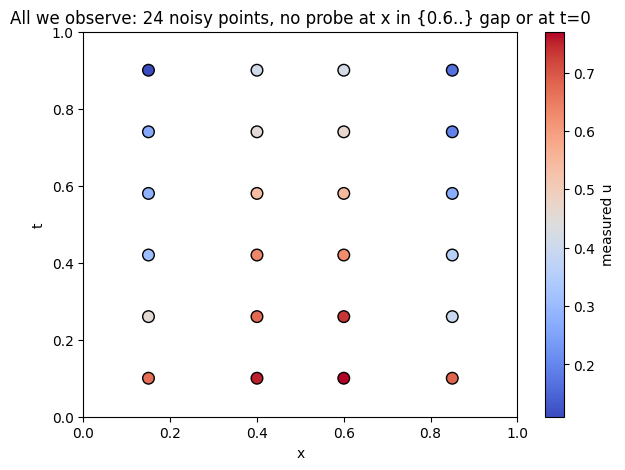

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
device = torch.device("cpu")

alpha, L, T = 0.10, 1.0, 1.0
def u_true(x, t):
    return np.sin(np.pi*x)*np.exp(-alpha*np.pi**2*t) + 0.5*np.sin(3*np.pi*x)*np.exp(-alpha*9*np.pi**2*t)

# --- sensors: only 4 locations, sampled at 6 times, and NONE at t=0 ---
sensor_x = np.array([0.15, 0.4, 0.6, 0.85])
sensor_t = np.linspace(0.1, 0.9, 6)
Xs, Ts = np.meshgrid(sensor_x, sensor_t); Xs, Ts = Xs.ravel(), Ts.ravel()
noise = 0.03
Us = u_true(Xs, Ts) + np.random.normal(0, noise, Xs.shape)
print(f"{len(Us)} noisy readings from {len(sensor_x)} probes, earliest at t={sensor_t[0]:.2f} (we never measure t=0)")

plt.figure(figsize=(7,5))
sc = plt.scatter(Xs, Ts, c=Us, cmap="coolwarm", s=70, edgecolor="k")
plt.colorbar(sc, label="measured u"); plt.xlim(0,1); plt.ylim(0,1)
plt.xlabel("x"); plt.ylabel("t"); plt.title("All we observe: 24 noisy points, no probe at x in {0.6..} gap or at t=0"); plt.show()

## 3. The PINN — nothing trainable but the field

The network is a plain $(x,t)\to u$ map, as in notebook 03. The loss fuses three known ingredients; crucially
there is **no unknown parameter** here — we are solving for the *field* that best explains the sensors while
obeying physics:

$$\mathcal{L} = \underbrace{\overline{(u_t-\alpha u_{xx})^2}}_{\text{known physics}}
\;+\; w_d\underbrace{\overline{(u(x_s,t_s)-u_s^{\text{meas}})^2}}_{\text{match sensors}}
\;+\; w_b\underbrace{\overline{u(0,t)^2+u(1,t)^2}}_{\text{known cold ends}}$$

We deliberately give **no initial condition** — recovering $u(x,0)$ is part of what we want to test.

In [2]:
class MLP(nn.Module):
    def __init__(self, hidden=40, n_hidden_layers=4):
        super().__init__()
        layers = [nn.Linear(2, hidden), nn.Tanh()]
        for _ in range(n_hidden_layers-1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

model = MLP().to(device)

def pde_residual(x, t):
    x = x.requires_grad_(True); t = t.requires_grad_(True)
    u = model(x, t)
    u_t  = torch.autograd.grad(u,  t, torch.ones_like(u),  create_graph=True)[0]
    u_x  = torch.autograd.grad(u,  x, torch.ones_like(u),  create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    return u_t - alpha*u_xx

# points
N_f = 1500
x_f = torch.rand(N_f,1, device=device)*L
t_f = torch.rand(N_f,1, device=device)*T
N_b = 200
t_b = torch.rand(N_b,1, device=device)*T
x_b0 = torch.zeros(N_b,1, device=device); x_bL = torch.ones(N_b,1, device=device)*L
xs = torch.tensor(Xs, dtype=torch.float32, device=device).reshape(-1,1)
ts = torch.tensor(Ts, dtype=torch.float32, device=device).reshape(-1,1)
us = torch.tensor(Us, dtype=torch.float32, device=device).reshape(-1,1)

w_d, w_b = 50.0, 20.0

iter     0 | loss 7.534e+00 | pde 6.85e-04 | data 1.28e-01 | bc 5.66e-02
iter  1000 | loss 2.715e-01 | pde 1.44e-02 | data 4.55e-03 | bc 1.47e-03
iter  2000 | loss 1.354e-01 | pde 5.37e-02 | data 1.36e-03 | bc 6.88e-04
iter  3000 | loss 1.086e-01 | pde 4.69e-02 | data 1.04e-03 | bc 4.93e-04
iter  4000 | loss 6.836e-02 | pde 2.63e-02 | data 7.31e-04 | bc 2.77e-04


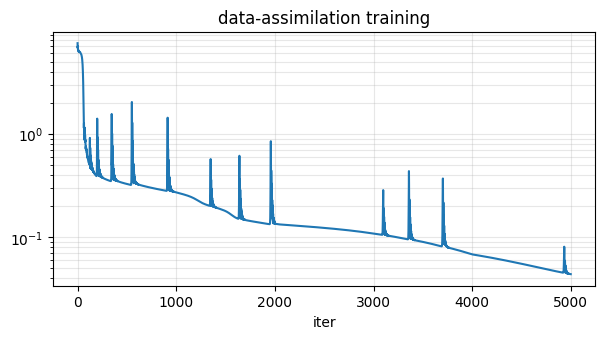

In [3]:
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

hist = []
for it in range(5000):                     # ~2-3 min on CPU
    optimizer.zero_grad()
    loss_pde  = torch.mean(pde_residual(x_f, t_f)**2)
    loss_data = torch.mean((model(xs, ts) - us)**2)
    loss_bc   = torch.mean(model(x_b0, t_b)**2) + torch.mean(model(x_bL, t_b)**2)
    loss = loss_pde + w_d*loss_data + w_b*loss_bc
    loss.backward(); optimizer.step(); scheduler.step()
    hist.append(loss.item())
    if it % 1000 == 0:
        print(f"iter {it:5d} | loss {loss.item():.3e} | pde {loss_pde.item():.2e} | data {loss_data.item():.2e} | bc {loss_bc.item():.2e}")
plt.figure(figsize=(7,3.3)); plt.semilogy(hist); plt.title("data-assimilation training"); plt.xlabel("iter"); plt.grid(True, which="both", alpha=0.3); plt.show()

## 4. Reconstruction vs hidden truth

We compare the assimilated field with the (secret) true field. Sensors are drawn as circles — notice large
regions with **no sensor at all** that the PINN still fills correctly, because the physics constrains them.

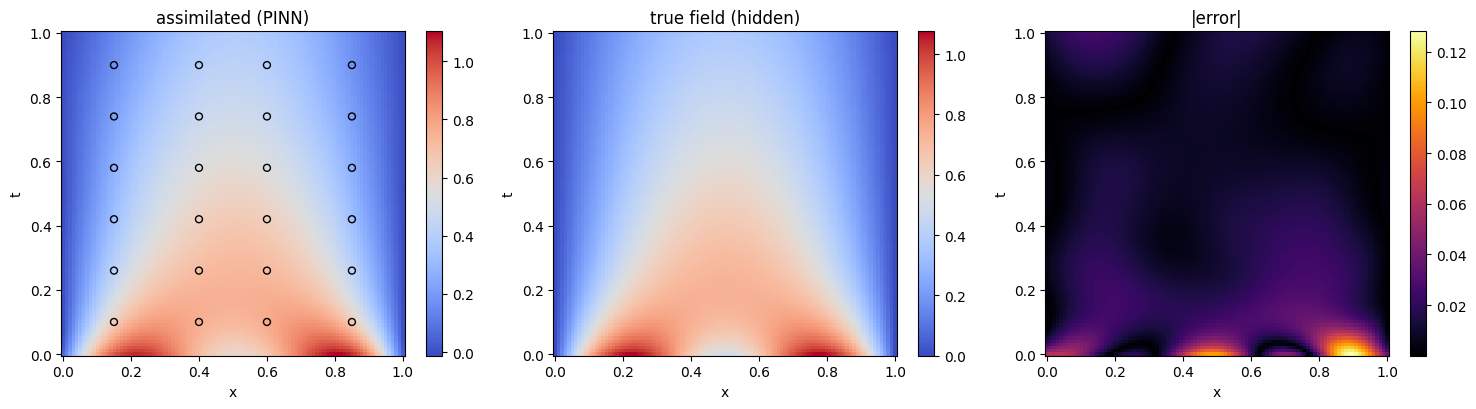

max abs reconstruction error: 0.12809685162812068


In [4]:
nx, nt = 100, 100
xg = np.linspace(0,L,nx); tg = np.linspace(0,T,nt)
Xg, Tg = np.meshgrid(xg, tg)
xx = torch.tensor(Xg.ravel(), dtype=torch.float32, device=device).reshape(-1,1)
tt = torch.tensor(Tg.ravel(), dtype=torch.float32, device=device).reshape(-1,1)
with torch.no_grad():
    U_pinn = model(xx, tt).cpu().numpy().reshape(nt, nx)
U_tru = u_true(Xg, Tg)

fig, axes = plt.subplots(1, 3, figsize=(15,4.2))
for ax, data, title in zip(axes, [U_pinn, U_tru, np.abs(U_pinn-U_tru)],
                           ["assimilated (PINN)", "true field (hidden)", "|error|"]):
    im = ax.pcolormesh(Xg, Tg, data, shading="auto", cmap="coolwarm" if "error" not in title else "inferno")
    ax.set_xlabel("x"); ax.set_ylabel("t"); ax.set_title(title); fig.colorbar(im, ax=ax)
axes[0].scatter(Xs, Ts, s=25, edgecolor="k", facecolor="none")
plt.tight_layout(); plt.show()
print("max abs reconstruction error:", np.max(np.abs(U_pinn-U_tru)))

## 5. Virtual sensor: predict where there is **no** probe

There is no sensor at $x=0.5$. Let's ask the assimilated field for the temperature history there and compare to
the truth — this is a **virtual sensor**, a real deliverable ("give me the temperature at a spot we cannot
instrument").

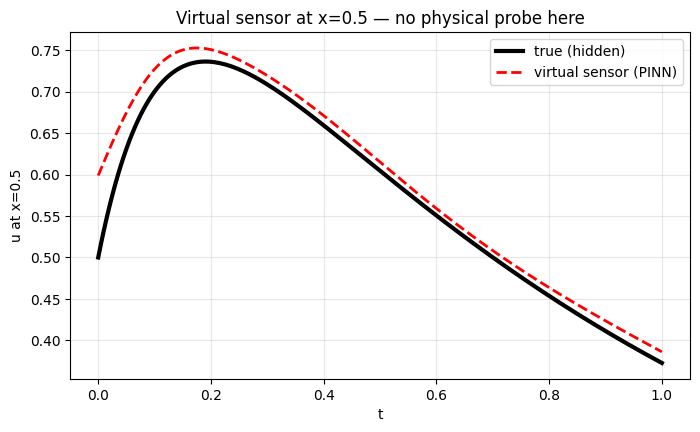

virtual-sensor max error: 0.09895563125610352


In [5]:
x_probe = 0.5
tline = torch.linspace(0, T, 200, device=device).reshape(-1,1)
xline = torch.full_like(tline, x_probe)
with torch.no_grad():
    u_virtual = model(xline, tline).cpu().numpy().flatten()
tt_np = tline.cpu().numpy().flatten()

plt.figure(figsize=(8,4.5))
plt.plot(tt_np, u_true(x_probe, tt_np), "k-", lw=3, label="true (hidden)")
plt.plot(tt_np, u_virtual, "r--", lw=2, label="virtual sensor (PINN)")
plt.xlabel("t"); plt.ylabel(f"u at x={x_probe}")
plt.title(f"Virtual sensor at x={x_probe} — no physical probe here"); plt.legend(); plt.grid(alpha=0.3); plt.show()
print("virtual-sensor max error:", np.max(np.abs(u_virtual - u_true(x_probe, tt_np))))

## 6. Denoising, and recovering the **unmeasured initial state**

Two more things the assimilation gives us for free:

- **Denoising** — at a real sensor location the PINN curve is smooth and physical, cutting through the noisy raw
  dots.
- **Recovering $t=0$** — we never measured the initial profile, yet the physics lets the PINN run the
  information *backwards* to reconstruct it.

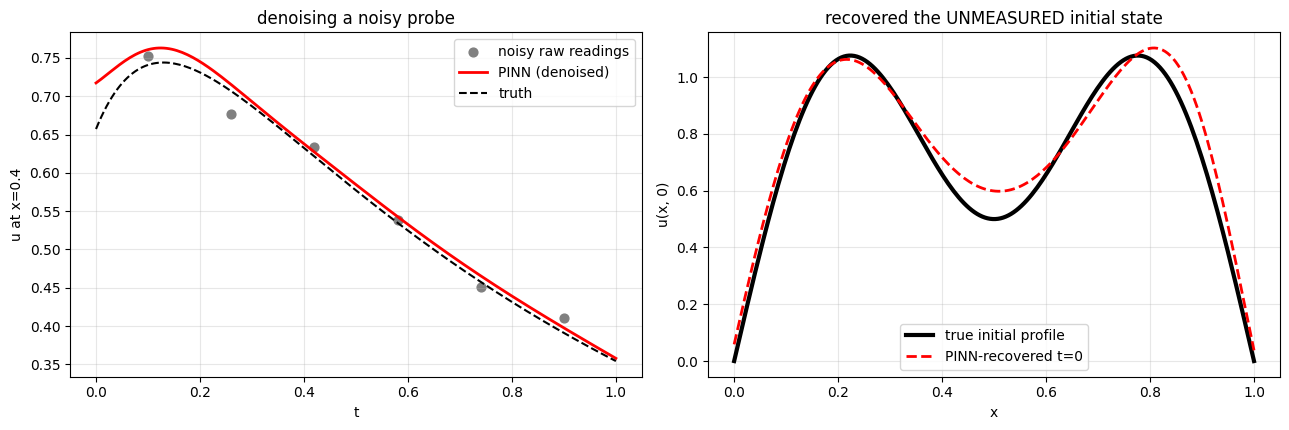

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))

# (a) denoising at a sensor column x=0.4
xs_col = 0.4
mask = np.isclose(Xs, xs_col)
ax[0].scatter(Ts[mask], Us[mask], color="gray", s=40, label="noisy raw readings")
tline = torch.linspace(0, T, 200, device=device).reshape(-1,1)
with torch.no_grad():
    u_col = model(torch.full_like(tline, xs_col), tline).cpu().numpy().flatten()
ax[0].plot(tline.cpu().numpy().flatten(), u_col, "r-", lw=2, label="PINN (denoised)")
ax[0].plot(tline.cpu().numpy().flatten(), u_true(xs_col, tline.cpu().numpy().flatten()), "k--", lw=1.5, label="truth")
ax[0].set_xlabel("t"); ax[0].set_ylabel(f"u at x={xs_col}"); ax[0].set_title("denoising a noisy probe"); ax[0].legend(); ax[0].grid(alpha=0.3)

# (b) recovered initial profile at t=0 (never measured)
xline = torch.linspace(0, L, 200, device=device).reshape(-1,1)
with torch.no_grad():
    u0 = model(xline, torch.zeros_like(xline)).cpu().numpy().flatten()
xl = xline.cpu().numpy().flatten()
ax[1].plot(xl, u_true(xl, 0.0), "k-", lw=3, label="true initial profile")
ax[1].plot(xl, u0, "r--", lw=2, label="PINN-recovered t=0")
ax[1].set_xlabel("x"); ax[1].set_ylabel("u(x, 0)"); ax[1].set_title("recovered the UNMEASURED initial state"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Why physics-based assimilation beats plain interpolation

If you fed the same 24 noisy points to a generic interpolator or a plain neural network with **no physics**, it
would:

- oscillate or flatten wildly in the big **sensor-free gaps**,
- have **no basis** to produce a virtual sensor far from data,
- be unable to recover the **$t=0$** state (no data there at all),
- happily **fit the noise**.

The physics term is what turns 24 messy points into a trustworthy field. This is the core value proposition of
data assimilation with PINNs — and it is exactly the first ✅ (*"fuse sparse/noisy sensors with physics"*) in the
"when to use a PINN" table.

> **Relationship to notebook 04:** identical machinery, different unknown. Here the physics is fully known and we
> solve for the **state**; in notebook 04 we *also* solved for an unknown **parameter**. Real digital twins
> usually do **both at once** — estimate the state *and* keep the parameters calibrated as data streams in.

## 8. Experiments

1. **Sensor dropout.** Delete the `x=0.6` probe (`sensor_x = np.array([0.15, 0.4, 0.85])`) and re-run. The
   reconstruction degrades gracefully — physics covers the widened gap.
2. **More noise.** Set `noise = 0.06`. The PINN still denoises well; raw points scatter, the field stays smooth.
3. **Fewer times.** Use `sensor_t = np.linspace(0.3, 0.9, 3)`. How far back in time can it still reconstruct
   $t=0$? This probes the limits of backward heat-equation assimilation (a famously ill-posed direction).

## 9. Recap

- **Data assimilation** = reconstruct the full state from sparse noisy sensors using **known** physics; nothing
  trainable but the field.
- The PDE **regularises** the fit, enabling **virtual sensors**, **denoising**, **gap-filling**, and even
  **recovering the unmeasured initial state**.
- Same loss recipe as notebook 04, minus the unknown parameter — and in practice you often do **state + parameter**
  together for a full digital twin.

That completes the two ✅ rows the core series pointed at: **sensor fusion / assimilation** (this notebook) and
**differentiable surrogate for control** (notebook 06).